In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


CustomerID:
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200]

Gender:
['Male' 'Female']

Age:
[19 21 20 23 31 22 35 64 30 67 58 24 37 52 25 46 54 29 45 40 60 53 18 49
 42 36 65 48 50 27 33 59 47 51 69 70 63 43 68 32 26 57 38 55 34 66 3

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print(df.columns.tolist())

['customerid', 'gender', 'age', 'annual_income_k$', 'spending_score_1-100']


In [11]:
df = df.rename(columns={
    "customerid": "customer_id",
    "annual_income_k$": "annual_income",
    "spending_score_1-100": "spending_score"
})

df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (200, 5)

Missing values:
customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

Duplicates: 0


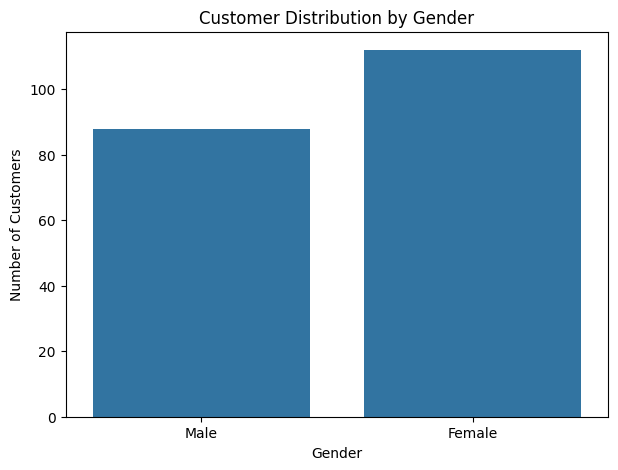

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

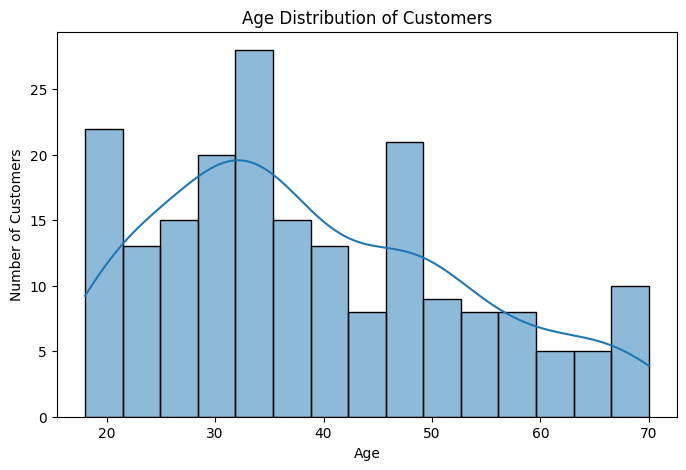

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

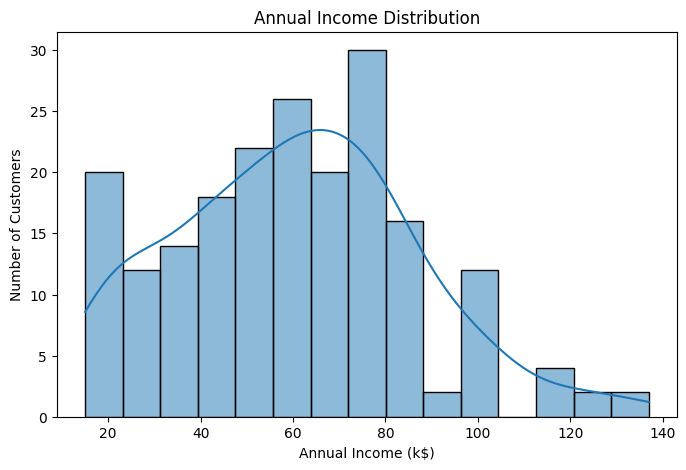

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["annual_income"], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

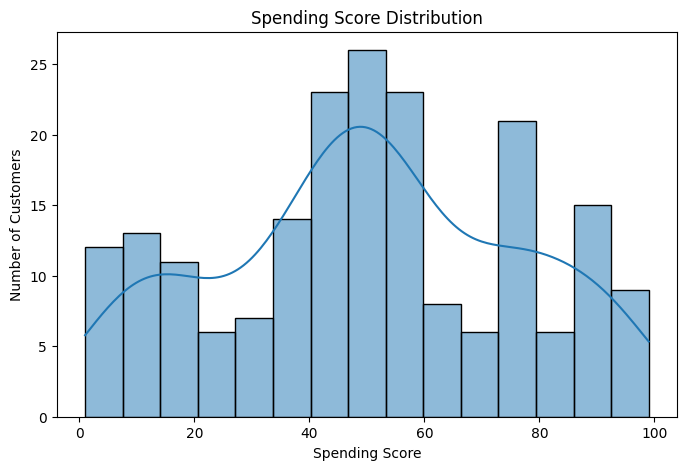

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["spending_score"], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

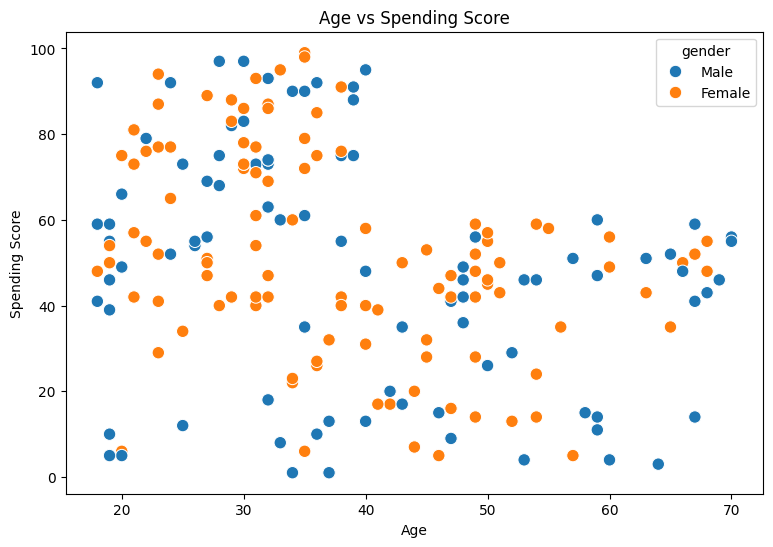

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="spending_score",
    hue="gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

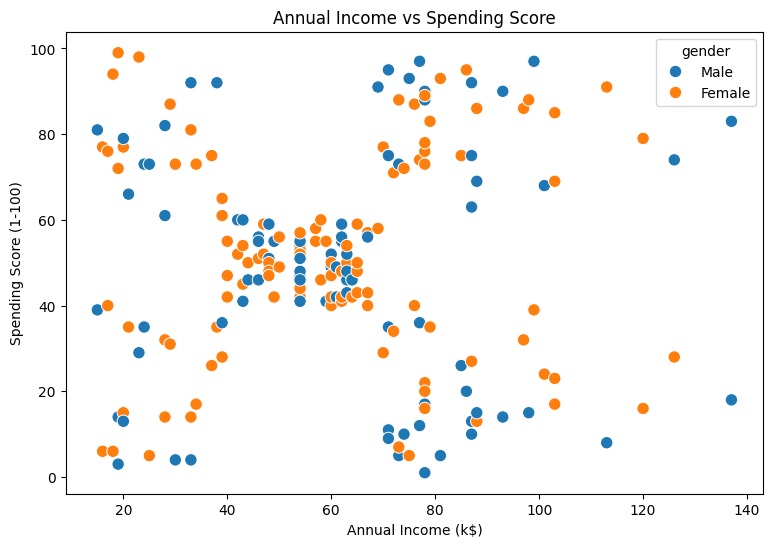

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="gender",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

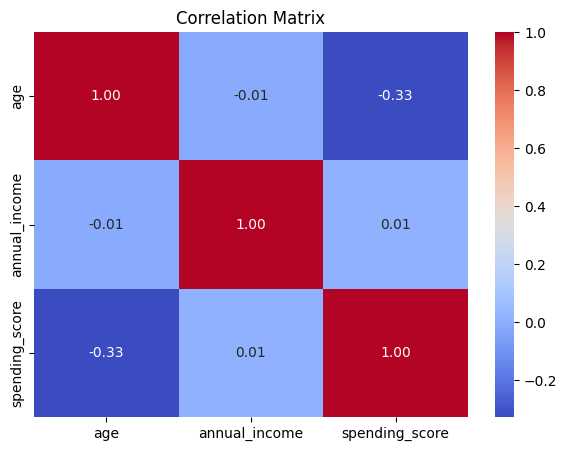

In [19]:
numeric_columns = [
    "age",
    "annual_income",
    "spending_score"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
X = df[["annual_income", "spending_score"]].copy()

print("Clustering features:")
print(X.head())

print("\nShape:", X.shape)

Clustering features:
   annual_income  spending_score
0             15              39
1             15              81
2             16               6
3             16              77
4             17              40

Shape: (200, 2)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Scaled data shape: (200, 2)

First 5 scaled rows:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [22]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

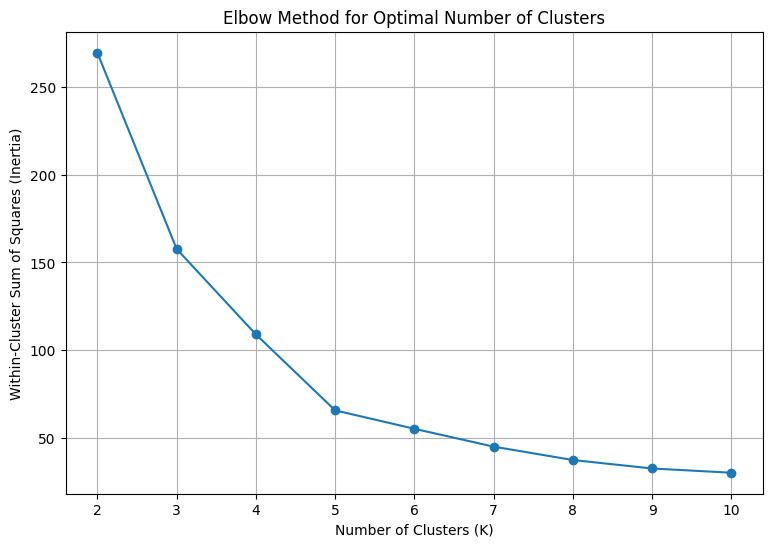

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

In [24]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number_of_Clusters": list(K_range),
    "Silhouette_Score": silhouette_scores
})

silhouette_results

,Number_of_Clusters,Silhouette_Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


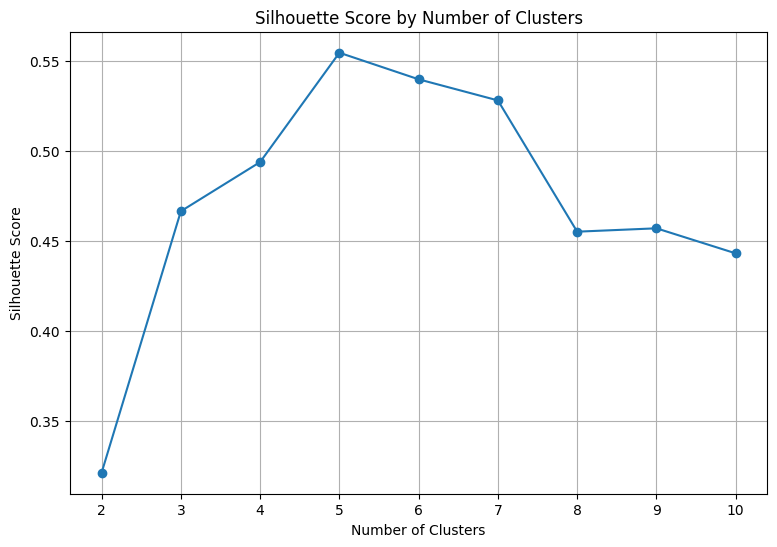

In [25]:
plt.figure(figsize=(9, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

In [26]:
OPTIMAL_K = 5

print("Selected number of clusters:", OPTIMAL_K)

Selected number of clusters: 5


In [27]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCluster distribution:")
print(df["cluster"].value_counts().sort_index())

K-Means clustering completed!

Cluster distribution:
cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


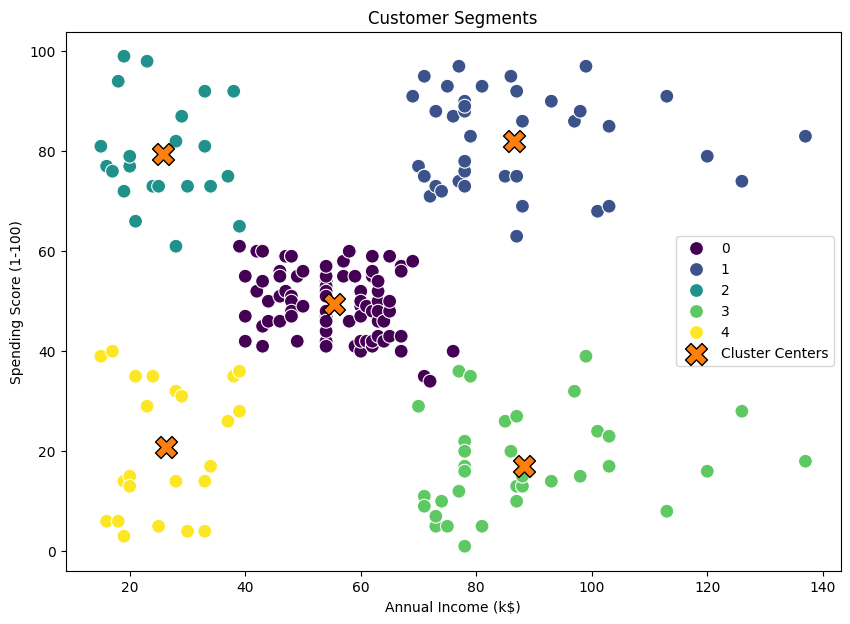

In [28]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="cluster",
    palette="viridis",
    s=100
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    label="Cluster Centers"
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [29]:
final_silhouette_score = silhouette_score(
    X_scaled,
    df["cluster"]
)

print(
    f"Final Silhouette Score: "
    f"{final_silhouette_score:.4f}"
)

Final Silhouette Score: 0.5547


In [30]:
cluster_summary = df.groupby("cluster").agg(
    customers=("customer_id", "count"),
    average_age=("age", "mean"),
    average_income=("annual_income", "mean"),
    average_spending_score=("spending_score", "mean")
).round(2)

cluster_summary

,customers,average_age,average_income,average_spending_score
cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [31]:
cluster_summary = cluster_summary.copy()

cluster_summary

,customers,average_age,average_income,average_spending_score
cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [32]:
income_median = df["annual_income"].median()
spending_median = df["spending_score"].median()

cluster_means = df.groupby("cluster")[
    ["annual_income", "spending_score"]
].mean()

def assign_segment(row):
    income = row["annual_income"]
    spending = row["spending_score"]

    if income >= income_median and spending >= spending_median:
        return "High-Value Customers"

    elif income >= income_median and spending < spending_median:
        return "High-Income Low-Spending"

    elif income < income_median and spending >= spending_median:
        return "Low-Income High-Spending"

    else:
        return "Low-Income Low-Spending"

segment_mapping = {}

for cluster, row in cluster_means.iterrows():
    segment_mapping[cluster] = assign_segment(row)

segment_mapping

{0: 'Low-Income Low-Spending',
 1: 'High-Value Customers',
 2: 'Low-Income High-Spending',
 3: 'High-Income Low-Spending',
 4: 'Low-Income Low-Spending'}

In [33]:
df["segment"] = df["cluster"].map(segment_mapping)

df[[
    "customer_id",
    "age",
    "annual_income",
    "spending_score",
    "cluster",
    "segment"
]].head(20)

,customer_id,age,annual_income,spending_score,cluster,segment
0,1,19,15,39,4,Low-Income Low-Spending
1,2,21,15,81,2,Low-Income High-Spending
2,3,20,16,6,4,Low-Income Low-Spending
3,4,23,16,77,2,Low-Income High-Spending
4,5,31,17,40,4,Low-Income Low-Spending
5,6,22,17,76,2,Low-Income High-Spending
6,7,35,18,6,4,Low-Income Low-Spending
7,8,23,18,94,2,Low-Income High-Spending
8,9,64,19,3,4,Low-Income Low-Spending
9,10,30,19,72,2,Low-Income High-Spending


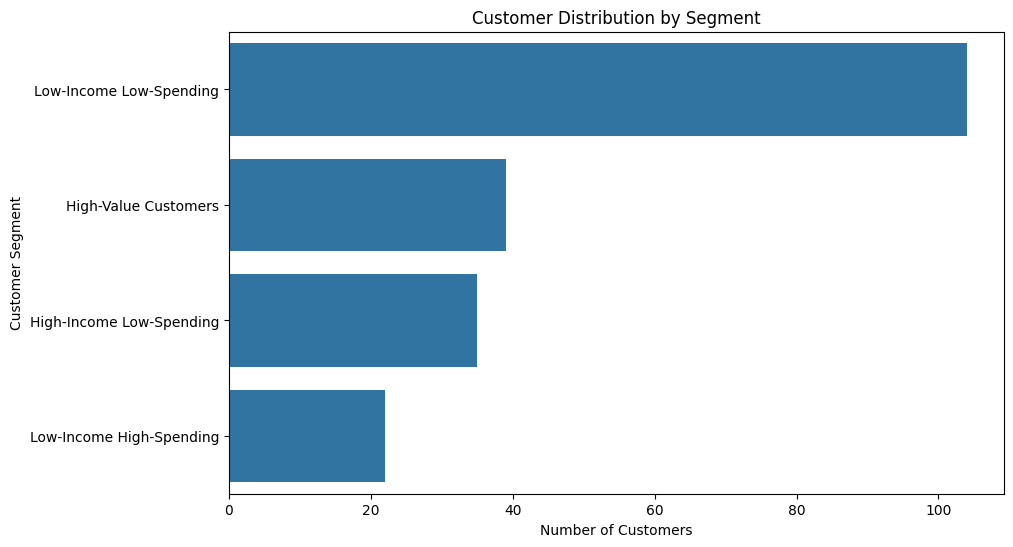

In [34]:
segment_counts = df["segment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.show()

In [35]:
segment_summary = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    average_age=("age", "mean"),
    average_income=("annual_income", "mean"),
    average_spending_score=("spending_score", "mean")
).sort_values(
    "average_spending_score",
    ascending=False
).round(2)

segment_summary

,customers,average_age,average_income,average_spending_score
segment,,,,
High-Value Customers,39,32.69,86.54,82.13
Low-Income High-Spending,22,25.27,25.73,79.36
Low-Income Low-Spending,104,43.27,48.88,43.19
High-Income Low-Spending,35,41.11,88.20,17.11


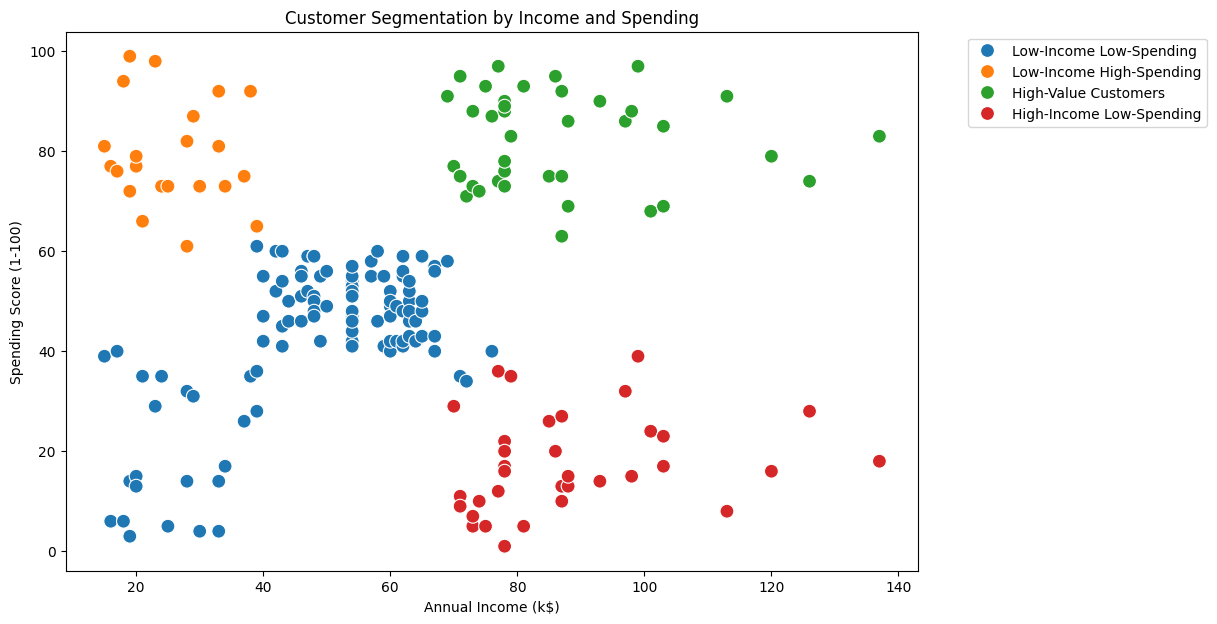

In [36]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="segment",
    s=100
)

plt.title("Customer Segmentation by Income and Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [37]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = df["cluster"].values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

Explained variance ratio:
[0.50495142 0.49504858]

Total explained variance: 1.0


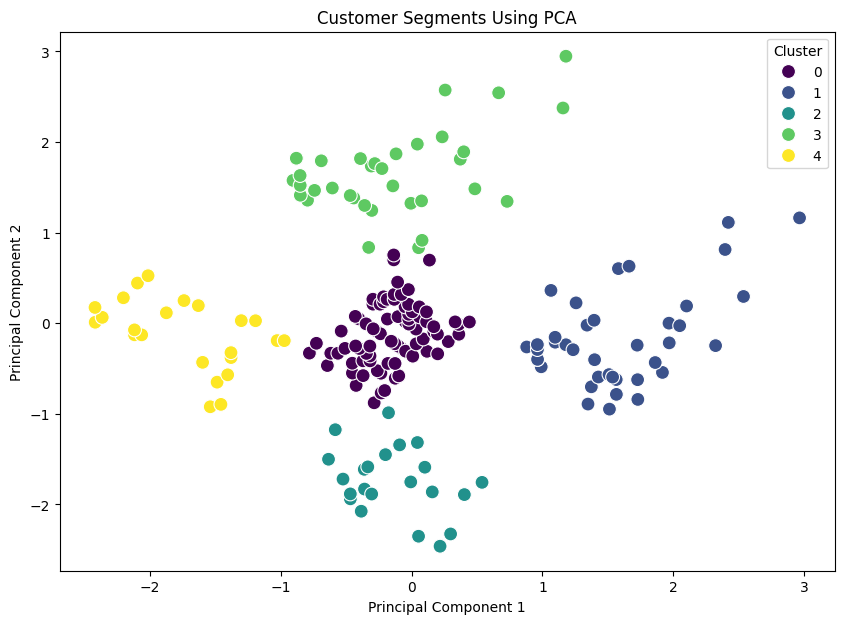

In [38]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [39]:
gender_segment = pd.crosstab(
    df["segment"],
    df["gender"]
)

gender_segment

gender,Female,Male
segment,,
High-Income Low-Spending,16,19
High-Value Customers,21,18
Low-Income High-Spending,13,9
Low-Income Low-Spending,62,42


In [40]:
gender_percentage = pd.crosstab(
    df["segment"],
    df["gender"],
    normalize="index"
).round(3) * 100

gender_percentage

gender,Female,Male
segment,,
High-Income Low-Spending,45.7,54.3
High-Value Customers,53.8,46.2
Low-Income High-Spending,59.1,40.9
Low-Income Low-Spending,59.6,40.4


In [41]:
age_analysis = df.groupby("segment")["age"].agg(
    ["mean", "min", "max"]
).round(2)

age_analysis

,mean,min,max
segment,,,
High-Income Low-Spending,41.11,19,59
High-Value Customers,32.69,27,40
Low-Income High-Spending,25.27,18,35
Low-Income Low-Spending,43.27,18,70


In [42]:
income_analysis = df.groupby("segment")["annual_income"].agg(
    ["mean", "min", "max"]
).round(2)

income_analysis

,mean,min,max
segment,,,
High-Income Low-Spending,88.20,70,137
High-Value Customers,86.54,69,137
Low-Income High-Spending,25.73,15,39
Low-Income Low-Spending,48.88,15,76


In [43]:
spending_analysis = df.groupby("segment")["spending_score"].agg(
    ["mean", "min", "max"]
).round(2)

spending_analysis

,mean,min,max
segment,,,
High-Income Low-Spending,17.11,1,39
High-Value Customers,82.13,63,97
Low-Income High-Spending,79.36,61,99
Low-Income Low-Spending,43.19,3,61


In [44]:
final_customer_data = df[[
    "customer_id",
    "gender",
    "age",
    "annual_income",
    "spending_score",
    "cluster",
    "segment"
]].copy()

final_customer_data.head(10)

,customer_id,gender,age,annual_income,spending_score,cluster,segment
0,1,Male,19,15,39,4,Low-Income Low-Spending
1,2,Male,21,15,81,2,Low-Income High-Spending
2,3,Female,20,16,6,4,Low-Income Low-Spending
3,4,Female,23,16,77,2,Low-Income High-Spending
4,5,Female,31,17,40,4,Low-Income Low-Spending
5,6,Female,22,17,76,2,Low-Income High-Spending
6,7,Female,35,18,6,4,Low-Income Low-Spending
7,8,Female,23,18,94,2,Low-Income High-Spending
8,9,Male,64,19,3,4,Low-Income Low-Spending
9,10,Female,30,19,72,2,Low-Income High-Spending


In [45]:
print("CUSTOMER SEGMENTATION BUSINESS RECOMMENDATIONS")
print("=" * 55)

print("""
1. High-Value Customers
   - Provide loyalty rewards and premium offers.
   - Introduce exclusive products and personalized promotions.
   - Focus on customer retention.

2. High-Income Low-Spending Customers
   - Use personalized offers to increase engagement.
   - Provide product recommendations based on preferences.
   - Investigate reasons for low spending.

3. Low-Income High-Spending Customers
   - Promote affordable bundles and discounts.
   - Use loyalty programs to encourage repeat purchases.
   - Avoid excessive premium pricing.

4. Low-Income Low-Spending Customers
   - Use budget-friendly promotions.
   - Target them with seasonal discounts.
   - Avoid spending excessive marketing resources.

5. Overall Strategy
   - Use customer segments for targeted marketing.
   - Personalize campaigns instead of using one strategy for all customers.
""")

CUSTOMER SEGMENTATION BUSINESS RECOMMENDATIONS

1. High-Value Customers
   - Provide loyalty rewards and premium offers.
   - Introduce exclusive products and personalized promotions.
   - Focus on customer retention.

2. High-Income Low-Spending Customers
   - Use personalized offers to increase engagement.
   - Provide product recommendations based on preferences.
   - Investigate reasons for low spending.

3. Low-Income High-Spending Customers
   - Promote affordable bundles and discounts.
   - Use loyalty programs to encourage repeat purchases.
   - Avoid excessive premium pricing.

4. Low-Income Low-Spending Customers
   - Use budget-friendly promotions.
   - Target them with seasonal discounts.
   - Avoid spending excessive marketing resources.

5. Overall Strategy
   - Use customer segments for targeted marketing.
   - Personalize campaigns instead of using one strategy for all customers.



In [46]:
df.to_csv(
    "customer_segments.csv",
    index=False
)

print("customer_segments.csv saved successfully!")

customer_segments.csv saved successfully!


In [47]:
joblib.dump(
    scaler,
    "customer_segmentation_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [48]:
joblib.dump(
    pca,
    "customer_segmentation_pca.pkl"
)

print("PCA model saved successfully!")

PCA model saved successfully!


In [49]:
joblib.dump(segment_mapping, "segment_mapping.pkl")
print("Segment mapping saved successfully!")

Segment mapping saved successfully!


In [50]:
segment_summary.to_csv(
    "segment_summary.csv"
)

print("segment_summary.csv saved successfully!")

segment_summary.csv saved successfully!


In [51]:
print("CUSTOMER SEGMENTATION PROJECT SUMMARY")
print("=" * 50)

print(f"Total Customers: {len(df)}")
print(f"Number of Segments: {OPTIMAL_K}")
print(f"Silhouette Score: {final_silhouette_score:.4f}")

print("\nSegments:")
for segment in df["segment"].unique():
    count = (df["segment"] == segment).sum()
    print(f"- {segment}: {count} customers")

CUSTOMER SEGMENTATION PROJECT SUMMARY
Total Customers: 200
Number of Segments: 5
Silhouette Score: 0.5547

Segments:
- Low-Income Low-Spending: 104 customers
- Low-Income High-Spending: 22 customers
- High-Value Customers: 39 customers
- High-Income Low-Spending: 35 customers


In [52]:
import os

print("Project files:")

for file in os.listdir():
    if (
        file.endswith(".csv")
        or file.endswith(".pkl")
        or file.endswith(".py")
    ):
        print("-", file)

Project files:
- Mall_Customers.csv
- customer_segmentation_pca.pkl
- customer_segments.csv
- segment_summary.csv
- segment_mapping.pkl
- customer_segmentation_scaler.pkl


In [53]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# -----------------------------
# Load trained model, scaler and segment mapping
# -----------------------------
kmeans = joblib.load("customer_segmentation_kmeans.pkl")
scaler = joblib.load("customer_segmentation_scaler.pkl")
segment_mapping = joblib.load("segment_mapping.pkl")

# -----------------------------
# Page configuration
# -----------------------------
st.set_page_config(
    page_title="Customer Segmentation",
    page_icon="👥",
    layout="centered"
)

# -----------------------------
# Title
# -----------------------------
st.title("👥 Customer Segmentation")

st.write(
    "Predict a customer's segment based on annual income "
    "and spending score using K-Means clustering."
)

st.divider()

# -----------------------------
# Customer inputs
# -----------------------------
st.subheader("Enter Customer Details")

annual_income = st.number_input(
    "Annual Income (k$)",
    min_value=0.0,
    max_value=200.0,
    value=60.0,
    step=1.0
)

spending_score = st.number_input(
    "Spending Score (1-100)",
    min_value=1.0,
    max_value=100.0,
    value=50.0,
    step=1.0
)

# -----------------------------
# Prediction
# -----------------------------
if st.button("Predict Customer Segment"):

    input_data = pd.DataFrame({
        "annual_income": [annual_income],
        "spending_score": [spending_score]
    })

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]

    # Map cluster to business segment
    segment = segment_mapping[cluster]

    # -----------------------------
    # Display result
    # -----------------------------
    st.success(f"Customer Segment: {segment}")

    st.metric(
        "Predicted Cluster",
        f"Cluster {cluster}"
    )

    st.write("### Customer Profile")

    result = pd.DataFrame({
        "Feature": [
            "Annual Income",
            "Spending Score",
            "Customer Segment"
        ],
        "Value": [
            f"{annual_income:.1f} k$",
            f"{spending_score:.1f}",
            segment
        ]
    })

    st.table(result)

    # -----------------------------
    # Business recommendation
    # -----------------------------
    st.write("### Recommended Strategy")

    if segment == "High-Value Customers":
        st.info(
            "Offer premium products, loyalty rewards, "
            "exclusive deals and personalized recommendations."
        )

    elif segment == "High-Income Low-Spending":
        st.info(
            "Use personalized promotions and targeted offers "
            "to increase customer engagement and spending."
        )

    elif segment == "Low-Income High-Spending":
        st.info(
            "Promote affordable bundles, discounts and loyalty "
            "programs to encourage repeat purchases."
        )

    else:
        st.info(
            "Focus on budget-friendly products, seasonal discounts "
            "and cost-effective marketing campaigns."
        )

st.divider()

st.caption(
    "Customer Segmentation Project | K-Means Clustering | Python & Streamlit"
)

Writing app.py


In [54]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [55]:
import os

print("Project files:")

for file in os.listdir():
    if file.endswith((".csv", ".pkl", ".py", ".txt")):
        print("-", file)

Project files:
- Mall_Customers.csv
- customer_segmentation_pca.pkl
- app.py
- requirements.txt
- customer_segments.csv
- segment_summary.csv
- segment_mapping.pkl
- customer_segmentation_scaler.pkl


In [56]:
import os

print("K-Means variable exists:", "kmeans" in globals())
print("Scaler variable exists:", "scaler" in globals())
print("Segment mapping exists:", "segment_mapping" in globals())

K-Means variable exists: True
Scaler variable exists: True
Segment mapping exists: True


In [57]:
import joblib

joblib.dump(kmeans, "customer_segmentation_kmeans.pkl")
joblib.dump(scaler, "customer_segmentation_scaler.pkl")
joblib.dump(segment_mapping, "segment_mapping.pkl")

print("All model files saved successfully!")

print("\nFiles created:")
print(os.path.exists("customer_segmentation_kmeans.pkl"))
print(os.path.exists("customer_segmentation_scaler.pkl"))
print(os.path.exists("segment_mapping.pkl"))

All model files saved successfully!

Files created:
True
True
True


In [58]:
import joblib

test_model = joblib.load("customer_segmentation_kmeans.pkl")
test_scaler = joblib.load("customer_segmentation_scaler.pkl")
test_mapping = joblib.load("segment_mapping.pkl")

print("K-Means model loaded successfully!")
print("Scaler loaded successfully!")
print("Segment mapping loaded successfully!")

K-Means model loaded successfully!
Scaler loaded successfully!
Segment mapping loaded successfully!


In [59]:
test_customer = pd.DataFrame({
    "annual_income": [80],
    "spending_score": [80]
})

test_scaled = test_scaler.transform(test_customer)

predicted_cluster = test_model.predict(test_scaled)[0]

predicted_segment = test_mapping[predicted_cluster]

print("Predicted Cluster:", predicted_cluster)
print("Predicted Segment:", predicted_segment)

Predicted Cluster: 1
Predicted Segment: High-Value Customers


In [60]:
! pkill -f streamlit

In [61]:
! streamlit --version

/bin/bash: line 1: streamlit: command not found


In [62]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [63]:
!cat streamlit.log

/bin/bash: line 1: streamlit: command not found


In [64]:
!wget -q -O - https://loca.lt/mytunnelpassword

136.113.42.144

In [65]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 3s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠦

In [ ]:
!lt --port 8501

your url is: https://silent-women-repair.loca.lt
